# Pricing Experimentation: Un Enfoque Causal

---

## Pregunta a responder:

> **¿Cuánto cambió el consumo de reservas en los mercados donde aumentamos el precio +5%/+10%/+15%, comparado con lo que hubiera ocurrido si no hubiéramos cambiado el precio?**

Este notebook implementa un análisis causal para estimar el efecto de cambios de precio sobre las reservas (bookings) utilizando **Synthetic Control Method (SCM)**.

### Referencias y fuentes:

- **Hernán & Robins** - *Causal Inference: What If* (2020)
- **Abadie, Diamond & Hainmueller** - *Synthetic Control Methods* (2010)
- **Abadie** - *Using Synthetic Controls* (2021)
- **Matheus Facure** - *Causal Inference for the Brave and True*

---

## 1. El Problema: A/B Testing e Inferencia Causal

### 1.1 Por qué A/B Testing falla en pricing

**Interferencia entre usuarios (violación de SUTVA)**

Los usuarios comparan precios entre sí. Las reseñas y el word-of-mouth propagan información de precios. El tratamiento de un usuario afecta el outcome de otros.

**Riesgo reputacional y discriminación percibida**

Mostrar precios diferentes a usuarios similares genera desconfianza. El price discrimination percibido daña la marca. Efectos de largo plazo no capturados en experimentos cortos.

**El precio es una policy, no un feature aislado**

Un feature se puede activar/desactivar por usuario. El precio es una decisión de negocio que aplica a todo un mercado. La unidad natural de experimentación es el **mercado geográfico**.

### 1.2 Conclusión: quasi-experimentos a nivel de mercado

Necesitamos quasi-experimentos donde algunos mercados reciben el tratamiento (aumento de precio), otros sirven como control, y estimamos el contrafactual mediante Synthetic Control.

el cociente %ΔQ / %ΔP es un estimador tipo Wald donde el SCM da la forma reducida y la exclusion restriction se sostiene porque Z solo afecta Y a través de P por diseño.

---

## 2. La Pregunta y el Target Trial

### 2.1 Target Trial: qué experimento estamos emulando

Siguiendo el framework de Hernán & Robins (Cap. 3), definimos el ensayo ideal:

| Componente | Especificación |
|------------|----------------|
| **Eligibility** | Mercados europeos con >50 bookings/día, sin promociones activas |
| **Treatment strategy** | Asignación Control, +5%, +10%, +15% |
| **Assignment** | Aleatorio a nivel de mercado |
| **Outcome** | Bookings diarios |
| **Start/End of follow-up** | Día de implementación / +45 días |
| **Causal contrast** | ATT por brazo vs control |

### 2.2 El DAG: Z → P → Y

```
       Z (Policy)              FX
    +5%|+10%|+15%|Ctrl          |
           |                    |
           v      First stage   v
           P (Precio PVP efectivo)
           |
           | Elasticidad
           v
           Y (Bookings) <------ Marketing, GDP, Seasonality
           ^
           |
           U (No observable: Competencia, Marca)
```

**Puntos clave:**
- El treatment es la **policy (Z)**, no el precio (P)
- El precio es un **mediador** entre Z e Y
- FX afecta al precio efectivo pero no es confusor de Z→Y
- U (Competencia, Marca) es confusor no observable - justifica usar SCM

### 2.3 Estimand: ATT por brazo

Average Treatment Effect on the Treated:

```
ATT_5%  = E[Y(1) - Y(0) | Z = +5%]
ATT_10% = E[Y(1) - Y(0) | Z = +10%]
ATT_15% = E[Y(1) - Y(0) | Z = +15%]
```

Todos comparados contra el mismo pool de control.

---

## 3. Asunciones de Identificación para SCM

### 3.1 No Anticipation

No hay efectos del tratamiento antes de su implementación. Los mercados no ajustan comportamiento anticipando el cambio de precio. **Verificación**: inspección visual del pre-periodo, conocimiento del negocio.

### 3.2 Convex Hull (Aproximabilidad)

El mercado tratado puede representarse como una combinación convexa de mercados de control. **Verificación**: RMSPE bajo en pre-periodo indica que el sintético replica bien al tratado.

### 3.3 Estabilidad Temporal

La relación entre el tratado y los controles que funciona en pre-periodo sigue siendo válida en post-periodo. No hay shocks estructurales que afecten diferencialmente al tratado.

### 3.4 Consistency (Intervención bien definida)

La intervención debe estar bien definida: "+X% sobre PVP inicial, sin tasas adicionales, ventana limpia sin promociones".

### 3.5 SUTVA (No interferencia entre mercados)

Los mercados no interfieren entre sí. **Verificación**: tráfico cruzado mínimo, monedas distintas.

---

**Nota importante**: A diferencia de DiD, SCM **no requiere parallel trends**. SCM es más flexible porque construye el contrafactual como combinación ponderada optimizada, no asume que tratado y control tendrían la misma pendiente. La validación se hace verificando el ajuste en pre-periodo (RMSPE).

---

## 4. Setup: Instalación y Carga de Datos

In [60]:
# Instalación de dependencias (descomentar en Colab)
# !pip install -q pandas numpy matplotlib seaborn scipy

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fmin_slsqp
from functools import partial
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [62]:
# Cargar datos desde local (Colab)
from google.colab import files
import io

# Subir archivo - selecciona 'pricing_experiment_data.csv'
print("Selecciona el archivo pricing_experiment_data.csv:")
uploaded = files.upload()

# Cargar el CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nDataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Periodo: {df['date'].min()} a {df['date'].max()}")
print(f"Mercados: {df['market'].unique()}")
print(f"Brazos de tratamiento: {df['treatment_arm'].unique()}")

Selecciona el archivo pricing_experiment_data.csv:


Saving dataset_pricing_v2_fixed.csv to dataset_pricing_v2_fixed (1).csv

Dataset: 4050 filas, 25 columnas
Periodo: 2024-01-01 a 2024-05-29
Mercados: ['AT' 'BE' 'BG' 'CH' 'CZ' 'DE' 'DK' 'ES' 'FI' 'FR' 'GR' 'HR' 'HU' 'IE'
 'IT' 'LT' 'LU' 'MX' 'NL' 'NO' 'PL' 'PT' 'RO' 'SE' 'SI' 'SK' 'UK']
Brazos de tratamiento: ['control' '+10%' '+5%' '+15%']


In [63]:
# Estructura de mercados y tratamientos
market_summary = df.groupby(['market', 'treatment_arm']).agg({
    'treatment_start_day': 'first',
    'wave': 'first',
    'bookings': 'mean'
}).reset_index()

print("Estructura del experimento:")
print(market_summary.to_string(index=False))

Estructura del experimento:
market treatment_arm  treatment_start_day  wave   bookings
    AT       control                    0     0 129.206667
    BE       control                    0     0 162.086667
    BG       control                    0     0 101.320000
    CH          +10%                  106     2 187.906667
    CZ       control                    0     0 187.806667
    DE       control                    0     0 548.400000
    DK       control                    0     0 518.193333
    ES           +5%                   91     1 436.333333
    FI       control                    0     0 356.800000
    FR       control                    0     0 492.793333
    GR       control                    0     0 210.026667
    HR       control                    0     0 155.240000
    HU       control                    0     0 173.573333
    IE       control                    0     0 396.433333
    IT           +5%                   91     1 410.080000
    LT       control        

---

## 5. El Diseño del Experimento

### 5.1 Definición operativa del treatment (Consistency)

- **+X% sobre PVP inicial**: sin tasas adicionales
- **Ventana limpia**: sin promociones ni cupones activos
- **Múltiples brazos** para estimar curva: +5%, +10%, +15% vs control

### 5.2 Selección de mercados

**Donor Pool (Control):** 19 mercados que nunca reciben tratamiento

**Mercados Tratados:**
- Wave 1 (+5%): ES, IT - día 91
- Wave 2 (+10%): CH, PL, UK - día 106  
- Wave 3 (+15%): RO, PT - día 121

### 5.3 Selección de mercados representativos para SCM

Seleccionamos UN mercado por brazo para el análisis SCM detallado:
- **ES** para +5% (mercado grande, eurozona)
- **UK** para +10% (mercado grande, fuera eurozona)
- **PT** para +15% (mercado mediano, eurozona)

In [64]:
# Definir estructura del experimento
CONTROL_MARKETS = ['AT','BE','BG','CZ','DE','DK','FI','FR','GR','HR','HU','IE','LT','LU','NL','NO','SE','SI','SK']

TREATED_MARKETS = {
    '+5%': {'markets': ['ES', 'IT'], 'representative': 'ES', 'treatment_day': 91},
    '+10%': {'markets': ['CH', 'PL', 'UK'], 'representative': 'UK', 'treatment_day': 106},
    '+15%': {'markets': ['RO', 'PT'], 'representative': 'PT', 'treatment_day': 121}
}

print("Donor Pool (Control):")
for m in CONTROL_MARKETS:
    avg_bookings = df[df['market'] == m]['bookings'].mean()
    print(f"  {m}: {avg_bookings:.0f} bookings/día promedio")

print("\nMercados Tratados (representativo para SCM):")
for arm, info in TREATED_MARKETS.items():
    rep = info['representative']
    avg_bookings = df[df['market'] == rep]['bookings'].mean()
    print(f"  {arm}: {rep} - {avg_bookings:.0f} bookings/día - tratamiento día {info['treatment_day']}")

Donor Pool (Control):
  AT: 129 bookings/día promedio
  BE: 162 bookings/día promedio
  BG: 101 bookings/día promedio
  CZ: 188 bookings/día promedio
  DE: 548 bookings/día promedio
  DK: 518 bookings/día promedio
  FI: 357 bookings/día promedio
  FR: 493 bookings/día promedio
  GR: 210 bookings/día promedio
  HR: 155 bookings/día promedio
  HU: 174 bookings/día promedio
  IE: 396 bookings/día promedio
  LT: 107 bookings/día promedio
  LU: 129 bookings/día promedio
  NL: 217 bookings/día promedio
  NO: 418 bookings/día promedio
  SE: 480 bookings/día promedio
  SI: 147 bookings/día promedio
  SK: 128 bookings/día promedio

Mercados Tratados (representativo para SCM):
  +5%: ES - 436 bookings/día - tratamiento día 91
  +10%: UK - 522 bookings/día - tratamiento día 106
  +15%: PT - 150 bookings/día - tratamiento día 121


---

## 6. Exploración de Datos y Verificación de First Stage

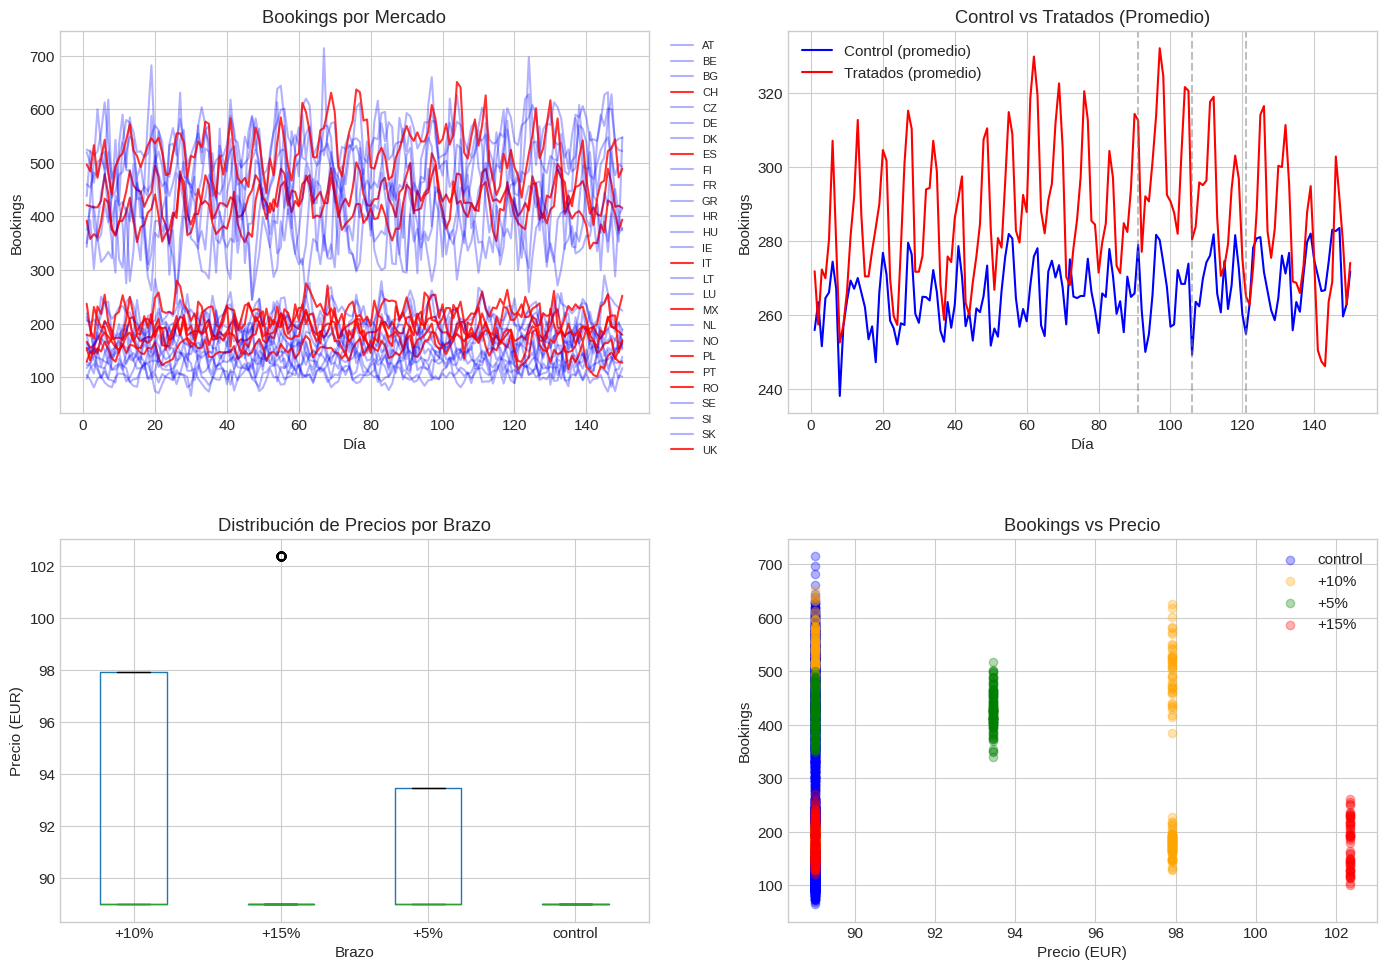

In [65]:
# Visualización: Series temporales por mercado
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Todos los mercados
ax = axes[0, 0]
for market in df['market'].unique():
    market_data = df[df['market'] == market]
    color = 'blue' if market in CONTROL_MARKETS else 'red'
    alpha = 0.3 if market in CONTROL_MARKETS else 0.8
    ax.plot(market_data['day_index'], market_data['bookings'],
            label=market, color=color, alpha=alpha)
ax.set_title('Bookings por Mercado')
ax.set_xlabel('Día')
ax.set_ylabel('Bookings')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Panel 2: Control vs Tratados agregados
ax = axes[0, 1]
control_avg = df[df['market'].isin(CONTROL_MARKETS)].groupby('day_index')['bookings'].mean()
treated_avg = df[~df['market'].isin(CONTROL_MARKETS)].groupby('day_index')['bookings'].mean()
ax.plot(control_avg.index, control_avg.values, label='Control (promedio)', color='blue')
ax.plot(treated_avg.index, treated_avg.values, label='Tratados (promedio)', color='red')
for arm, info in TREATED_MARKETS.items():
    ax.axvline(x=info['treatment_day'], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Control vs Tratados (Promedio)')
ax.set_xlabel('Día')
ax.set_ylabel('Bookings')
ax.legend()

# Panel 3: Distribución de precios por brazo
ax = axes[1, 0]
df.boxplot(column='price_eur', by='treatment_arm', ax=ax)
ax.set_title('Distribución de Precios por Brazo')
ax.set_xlabel('Brazo')
ax.set_ylabel('Precio (EUR)')
plt.suptitle('')

# Panel 4: Bookings vs Precio
ax = axes[1, 1]
colors = {'control': 'blue', '+5%': 'green', '+10%': 'orange', '+15%': 'red'}
for arm in df['treatment_arm'].unique():
    arm_data = df[df['treatment_arm'] == arm]
    ax.scatter(arm_data['price_eur'], arm_data['bookings'],
               alpha=0.3, label=arm, color=colors.get(arm, 'gray'))
ax.set_title('Bookings vs Precio')
ax.set_xlabel('Precio (EUR)')
ax.set_ylabel('Bookings')
ax.legend()

plt.tight_layout()
plt.show()

In [66]:
# Verificar First Stage: La policy (Z) realmente movió el precio (P)?
print("VERIFICACIÓN FIRST STAGE: Z → P")
print("="*50)

for arm, info in TREATED_MARKETS.items():
    rep = info['representative']
    t_day = info['treatment_day']

    market_data = df[df['market'] == rep]

    pre_price = market_data[market_data['day_index'] < t_day]['price_eur'].mean()
    post_price = market_data[market_data['day_index'] >= t_day]['price_eur'].mean()
    actual_uplift = (post_price - pre_price) / pre_price * 100

    nominal_uplift = float(arm.replace('%', '').replace('+', ''))

    print(f"\n{rep} ({arm}):")
    print(f"  Precio pre:  {pre_price:.2f} EUR")
    print(f"  Precio post: {post_price:.2f} EUR")
    print(f"  Uplift nominal: {nominal_uplift:.1f}%")
    print(f"  Uplift realizado: {actual_uplift:.1f}%")
    print(f"  Compliance: {'✓ OK' if abs(actual_uplift - nominal_uplift) < 2 else '⚠️ REVISAR'}")

VERIFICACIÓN FIRST STAGE: Z → P

ES (+5%):
  Precio pre:  89.00 EUR
  Precio post: 93.45 EUR
  Uplift nominal: 5.0%
  Uplift realizado: 5.0%
  Compliance: ✓ OK

UK (+10%):
  Precio pre:  89.00 EUR
  Precio post: 97.90 EUR
  Uplift nominal: 10.0%
  Uplift realizado: 10.0%
  Compliance: ✓ OK

PT (+15%):
  Precio pre:  89.00 EUR
  Precio post: 102.35 EUR
  Uplift nominal: 15.0%
  Uplift realizado: 15.0%
  Compliance: ✓ OK


---

## 7. Metodología: Synthetic Control Method

### 7.1 Intuición

El SCM construye un "clon" del mercado tratado usando una combinación ponderada de mercados de control. Los pesos se optimizan para minimizar la diferencia en el pre-periodo.

### 7.2 Formalización

Minimizamos:

```
min_W ||Y_treated_pre - Y_controls_pre · W||²
```

sujeto a: `sum(W) = 1`, `W >= 0`

El contrafactual post-tratamiento es: `Y_synthetic_post = Y_controls_post · W`

### 7.3 Diagnóstico clave: RMSPE pre-periodo

```
RMSPE = sqrt(mean((Y_treated - Y_synthetic)²)) en pre-periodo
```

Un RMSPE bajo indica buen ajuste y valida la asunción de aproximabilidad (convex hull).

In [67]:
# =============================================================================
# SCM con covariate matching (Abadie 2010)
# Covariables seleccionadas por el DAG: variables con flecha directa a Y
#
# NO incluimos: price_eur (idéntico pre-treatment), revenue (función de Y),
# ltv/churn/cr (guardrails, no causas de Y en el DAG)
# =============================================================================

def loss_w(w, X, y):
    """Función de pérdida: RMSPE entre tratado y sintético."""
    return np.sqrt(np.mean((y - X.dot(w))**2))

def get_synthetic_weights(X, y):
    """Obtiene los pesos óptimos W para el control sintético."""
    n_controls = X.shape[1]
    w_start = np.array([1/n_controls] * n_controls)

    weights = fmin_slsqp(
        partial(loss_w, X=X, y=y),
        w_start,
        f_eqcons=lambda w: np.sum(w) - 1,
        bounds=[(0.0, 1.0)] * n_controls,
        disp=False
    )
    return weights

def compute_covariate_features(df, market, treatment_day):
    """
    Calcula features pre-tratamiento para un mercado.
    Guiado por el DAG: solo variables con flecha directa a Y.
    """
    market_data = df[df['market'] == market].sort_values('day_index')
    pre_data = market_data[market_data['day_index'] < treatment_day]

    bookings_mean = pre_data['bookings'].mean()

    t = np.arange(len(pre_data))
    bookings_trend = np.polyfit(t, pre_data['bookings'].values, 1)[0] if len(t) > 1 else 0.0

    weekend_bookings = pre_data[pre_data['is_weekend'] == 1]['bookings'].mean()
    weekday_bookings = pre_data[pre_data['is_weekend'] == 0]['bookings'].mean()
    weekend_ratio = weekend_bookings / weekday_bookings if weekday_bookings > 0 else 1.0

    sessions_mean = pre_data['sessions'].mean()
    gdp = pre_data['gdp_per_capita'].mean()
    marketing_mean = pre_data['marketing_spend_eur'].mean()

    return np.array([
        bookings_mean,
        bookings_trend,
        weekend_ratio,
        sessions_mean,
        gdp,
        marketing_mean
    ])

COVARIATE_NAMES = ['bookings_mean', 'bookings_trend', 'weekend_ratio',
                   'sessions', 'gdp_per_capita', 'marketing_spend']

def diagnose_positivity(weights, control_markets):
    """Diagnóstico de Positivity: verifica que los pesos no estén degenerados."""
    effective_donors = sum(1 for w in weights if w > 0.05)
    hhi = sum(w**2 for w in weights)
    max_weight = max(weights)

    return {
        'effective_donors': effective_donors,
        'total_donors': len(weights),
        'hhi': hhi,
        'max_weight': max_weight,
        'positivity_ok': effective_donors >= 2 and max_weight < 0.9
    }

def report_covariate_balance(treated_features, control_features, weights, covariate_names):
    """
    Compara covariables del tratado vs sintético ponderado.
    Standardized Mean Difference (SMD): <0.25 es aceptable en SCM.
    Esto verifica que el sintético no solo replica la serie temporal,
    sino también las características estructurales del mercado tratado.
    """
    synthetic_features = control_features.T.dot(weights)

    control_std = control_features.std(axis=0)
    control_std[control_std == 0] = 1.0
    smd = (treated_features - synthetic_features) / control_std

    print(f"  Covariate Balance (DAG-guided):")
    print(f"    {'Covariable':<20} {'Tratado':>10} {'Sintético':>10} {'SMD':>8} {'':>5}")
    print(f"    {'-'*55}")
    all_ok = True
    for i, name in enumerate(covariate_names):
        ok = abs(smd[i]) < 0.25
        if not ok:
            all_ok = False
        print(f"    {name:<20} {treated_features[i]:>10.1f} {synthetic_features[i]:>10.1f} {smd[i]:>+8.3f} {'✓' if ok else '⚠️':>5}")

    status = "✓ Balance aceptable (todos SMD < 0.25)" if all_ok else "⚠️ Desbalance en alguna covariable"
    print(f"    {status}")
    return all_ok

def compute_synthetic_control(df, treated_market, control_markets, treatment_day, outcome='bookings'):
    """
    SCM con covariate matching (Abadie 2010).

    Para outcome='bookings': augmenta la serie temporal pre-tratamiento
    con pseudo-observaciones de covariables del DAG, de modo que el
    optimizador busca W que matchee tanto la serie como las covariables.

    Para otros outcomes (guardrails): solo serie temporal.
    """
    all_markets = [treated_market] + control_markets

    wide = df[df['market'].isin(all_markets)].pivot(
        index='day_index',
        columns='market',
        values=outcome
    )

    pre_data = wide[wide.index < treatment_day]
    y_pre = pre_data[treated_market].values
    X_pre = pre_data[control_markets].values

    v_weights = None
    control_features_matrix = None
    treated_features_vec = None

    if outcome == 'bookings':
        # --- Covariate matching guiado por DAG ---
        treated_features_vec = compute_covariate_features(df, treated_market, treatment_day)
        control_features_matrix = np.array([
            compute_covariate_features(df, m, treatment_day)
            for m in control_markets
        ])  # shape: (n_controls, n_features)

        n_features = len(treated_features_vec)
        n_controls = len(control_markets)

        # Normalizar covariables (z-score) para que escala no domine
        feat_mean = control_features_matrix.mean(axis=0)
        feat_std = control_features_matrix.std(axis=0)
        feat_std[feat_std == 0] = 1.0

        treated_norm = (treated_features_vec - feat_mean) / feat_std
        control_norm = (control_features_matrix - feat_mean) / feat_std

        # Optimizar V (importancia de covariables) via grid search
        best_rmspe = np.inf
        best_v = np.ones(n_features) / n_features
        best_w = None

        np.random.seed(123)
        v_candidates = [np.ones(n_features) / n_features]
        for _ in range(50):
            v_rand = np.random.dirichlet(np.ones(n_features))
            v_candidates.append(v_rand)

        for v_cand in v_candidates:
            scale = np.sqrt(len(y_pre))

            y_cov = treated_norm * np.sqrt(v_cand) * scale
            X_cov = (control_norm * np.sqrt(v_cand).reshape(1, -1) * scale).T

            y_aug = np.concatenate([y_pre, y_cov])
            X_aug = np.concatenate([X_pre, X_cov], axis=0)

            try:
                w_cand = get_synthetic_weights(X_aug, y_aug)
                rmspe_cand = np.sqrt(np.mean((y_pre - X_pre.dot(w_cand))**2))

                if rmspe_cand < best_rmspe:
                    best_rmspe = rmspe_cand
                    best_v = v_cand
                    best_w = w_cand
            except:
                continue

        weights = best_w if best_w is not None else get_synthetic_weights(X_pre, y_pre)
        v_weights = best_v

    else:
        # Para guardrails: solo serie temporal
        weights = get_synthetic_weights(X_pre, y_pre)

    positivity_diag = diagnose_positivity(weights, control_markets)

    # Construir contrafactual
    X_full = wide[control_markets].values
    synthetic_series = X_full.dot(weights)
    treated_series = wide[treated_market].values
    effect_series = treated_series - synthetic_series

    pre_effect = effect_series[:treatment_day-1]
    rmspe_pre = np.sqrt(np.mean(pre_effect**2))
    day_index = wide.index.values

    result = {
        'weights': dict(zip(control_markets, weights)),
        'synthetic': synthetic_series,
        'treated': treated_series,
        'effect': effect_series,
        'day_index': day_index,
        'treatment_day': treatment_day,
        'rmspe_pre': rmspe_pre,
        'market': treated_market,
        'positivity': positivity_diag
    }

    if outcome == 'bookings' and v_weights is not None:
        result['covariate_importance'] = dict(zip(COVARIATE_NAMES, v_weights))
        result['treated_features'] = dict(zip(COVARIATE_NAMES, treated_features_vec))
        result['control_features_matrix'] = control_features_matrix
        result['treated_features_vec'] = treated_features_vec

    return result

print("Funciones de Synthetic Control con covariate matching (DAG-guided) definidas.")
print(f"Covariables del DAG: {', '.join(COVARIATE_NAMES)}")
print(f"Diagnósticos incluidos: Positivity, Covariate Balance (SMD)")

Funciones de Synthetic Control con covariate matching (DAG-guided) definidas.
Covariables del DAG: bookings_mean, bookings_trend, weekend_ratio, sessions, gdp_per_capita, marketing_spend
Diagnósticos incluidos: Positivity, Covariate Balance (SMD)


---

## 8. SCM para cada Brazo de Tratamiento

In [68]:
# =============================================================================
# Calcular SCM para cada mercado representativo
# =============================================================================
results = {}

for arm, info in TREATED_MARKETS.items():
    rep = info['representative']
    t_day = info['treatment_day']

    print(f"\nCalculando SCM para {rep} ({arm})...")

    scm = compute_synthetic_control(
        df=df,
        treated_market=rep,
        control_markets=CONTROL_MARKETS,
        treatment_day=t_day
    )

    results[arm] = scm

    print(f"  RMSPE pre-periodo: {scm['rmspe_pre']:.2f}")
    print(f"  Pesos del sintético:")
    for market, weight in scm['weights'].items():
        if weight > 0.01:
            print(f"    {market}: {weight:.3f}")

    pos = scm['positivity']
    print(f"  Diagnóstico Positivity:")
    print(f"    Donors efectivos: {pos['effective_donors']}/{pos['total_donors']}")
    print(f"    HHI (concentración): {pos['hhi']:.3f} {'✓' if pos['hhi'] < 0.5 else '⚠️ Alta concentración'}")

    # Importancia de covariables (V del outer loop)
    if 'covariate_importance' in scm:
        print(f"  Importancia covariables (V, DAG-guided):")
        for cov, imp in sorted(scm['covariate_importance'].items(), key=lambda x: -x[1]):
            bar = '█' * int(imp * 30)
            print(f"    {cov:20s}: {imp:.3f} {bar}")

    # Covariate Balance: ¿el sintético replica las características del tratado?
    if 'control_features_matrix' in scm:
        weights_array = np.array([scm['weights'][m] for m in CONTROL_MARKETS])
        report_covariate_balance(
            treated_features=scm['treated_features_vec'],
            control_features=scm['control_features_matrix'],
            weights=weights_array,
            covariate_names=COVARIATE_NAMES
        )


Calculando SCM para ES (+5%)...
  RMSPE pre-periodo: 16.97
  Pesos del sintético:
    CZ: 0.137
    DE: 0.489
    DK: 0.016
    FR: 0.123
    IE: 0.030
    NO: 0.069
    SE: 0.049
    SK: 0.084
  Diagnóstico Positivity:
    Donors efectivos: 5/19
    HHI (concentración): 0.289 ✓
  Importancia covariables (V, DAG-guided):
    sessions            : 0.465 █████████████
    bookings_mean       : 0.200 ██████
    weekend_ratio       : 0.176 █████
    gdp_per_capita      : 0.070 ██
    marketing_spend     : 0.067 ██
    bookings_trend      : 0.021 
  Covariate Balance (DAG-guided):
    Covariable              Tratado  Sintético      SMD      
    -------------------------------------------------------
    bookings_mean             433.2      433.0   +0.001     ✓
    bookings_trend              0.2        0.2   +0.555    ⚠️
    weekend_ratio               1.1        1.1   +0.119     ✓
    sessions                13653.9    13647.9   +0.001     ✓
    gdp_per_capita          30000.0    45815.1

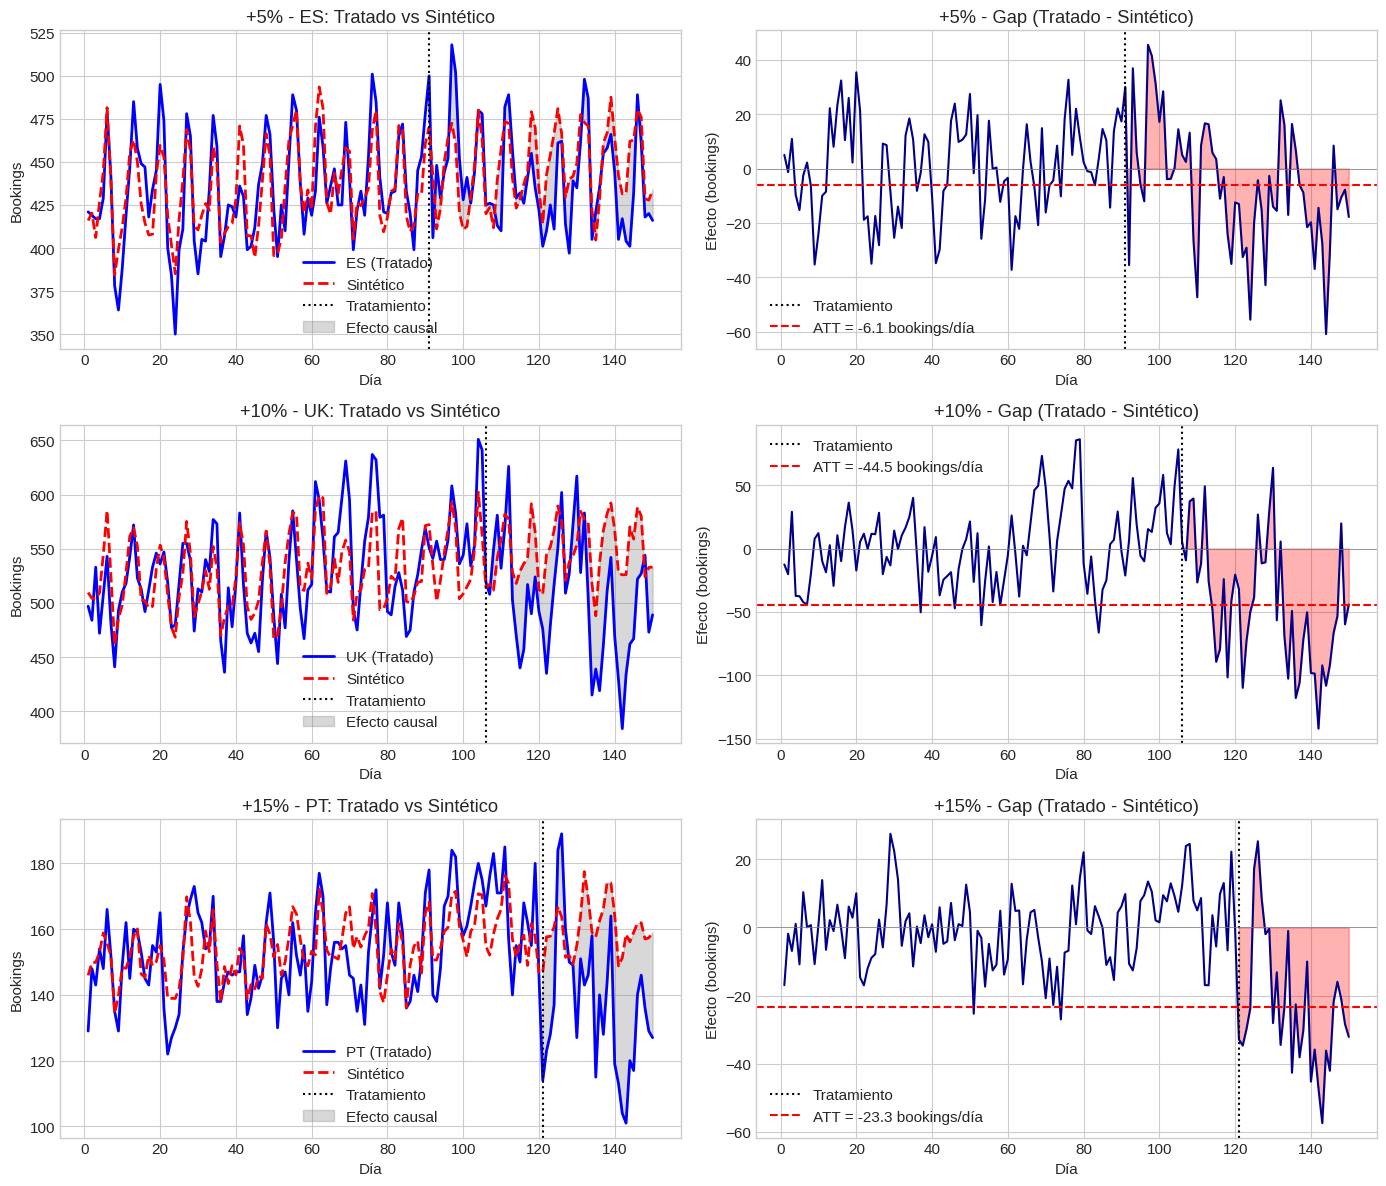

In [69]:
# Visualizar resultados SCM
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, (arm, scm) in enumerate(results.items()):
    t_day = scm['treatment_day']
    day_idx = scm['day_index']

    # Panel izquierdo: Series temporales
    ax = axes[idx, 0]
    ax.plot(day_idx, scm['treated'], label=f'{scm["market"]} (Tratado)', color='blue', linewidth=2)
    ax.plot(day_idx, scm['synthetic'], label='Sintético', color='red', linestyle='--', linewidth=2)
    ax.axvline(x=t_day, color='black', linestyle=':', label='Tratamiento')
    ax.fill_between(day_idx[day_idx >= t_day],
                    scm['treated'][day_idx >= t_day],
                    scm['synthetic'][day_idx >= t_day],
                    alpha=0.3, color='gray', label='Efecto causal')
    ax.set_title(f'{arm} - {scm["market"]}: Tratado vs Sintético')
    ax.set_xlabel('Día')
    ax.set_ylabel('Bookings')
    ax.legend(loc='best')

    # Panel derecho: Gap (efecto)
    ax = axes[idx, 1]
    ax.plot(day_idx, scm['effect'], color='darkblue', linewidth=1.5)
    ax.axvline(x=t_day, color='black', linestyle=':', label='Tratamiento')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax.fill_between(day_idx, 0, scm['effect'],
                    where=(day_idx >= t_day),
                    alpha=0.3, color='red')

    att = np.mean(scm['effect'][day_idx >= t_day])
    ax.axhline(y=att, color='red', linestyle='--',
               label=f'ATT = {att:.1f} bookings/día')

    ax.set_title(f'{arm} - Gap (Tratado - Sintético)')
    ax.set_xlabel('Día')
    ax.set_ylabel('Efecto (bookings)')
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

---

## 9. Validación: Placebo Tests e Inferencia

### 9.1 El problema de inferencia en SCM

Con Synthetic Control, no tenemos errores estándar tradicionales. Usamos **placebo tests** (Abadie et al., 2010):

1. Aplicamos SCM a cada mercado de control como si fuera tratado
2. Comparamos el efecto estimado del tratado real vs. los efectos "placebo"
3. Si el efecto real es extremo respecto a los placebos, es significativo

**Limitación importante**: Con solo 5 mercados de control, el p-value mínimo posible es 1/6 ≈ 0.167.

PLACEBO TESTS (FISHER'S EXACT INFERENCE)

──────────────────────────────────────────────────
Brazo +5% (ES) - Treatment day 91
──────────────────────────────────────────────────
  Tratado (ES): RMSPE pre=17.0, post=23.9, ratio=1.41
  Placebo (AT): RMSPE pre=9.9, post=11.2, ratio=1.13
  Placebo (BE): RMSPE pre=9.7, post=11.2, ratio=1.15
  Placebo (BG): RMSPE pre=15.0, post=22.7, ratio=1.52
  Placebo (CZ): RMSPE pre=20.0, post=21.7, ratio=1.09
  Placebo (DE): RMSPE pre=50.5, post=62.6, ratio=1.24
  Placebo (DK): RMSPE pre=52.2, post=57.4, ratio=1.10
  Placebo (FI): RMSPE pre=45.7, post=47.8, ratio=1.04
  Placebo (FR): RMSPE pre=24.6, post=26.4, ratio=1.07
  Placebo (GR): RMSPE pre=22.4, post=25.2, ratio=1.12
  Placebo (HR): RMSPE pre=18.2, post=22.2, ratio=1.22
  Placebo (HU): RMSPE pre=18.9, post=19.8, ratio=1.05
  Placebo (IE): RMSPE pre=55.7, post=57.6, ratio=1.04
  Placebo (LT): RMSPE pre=15.2, post=17.7, ratio=1.16
  Placebo (LU): RMSPE pre=16.9, post=19.1, ratio=1.13
  Placebo (NL)

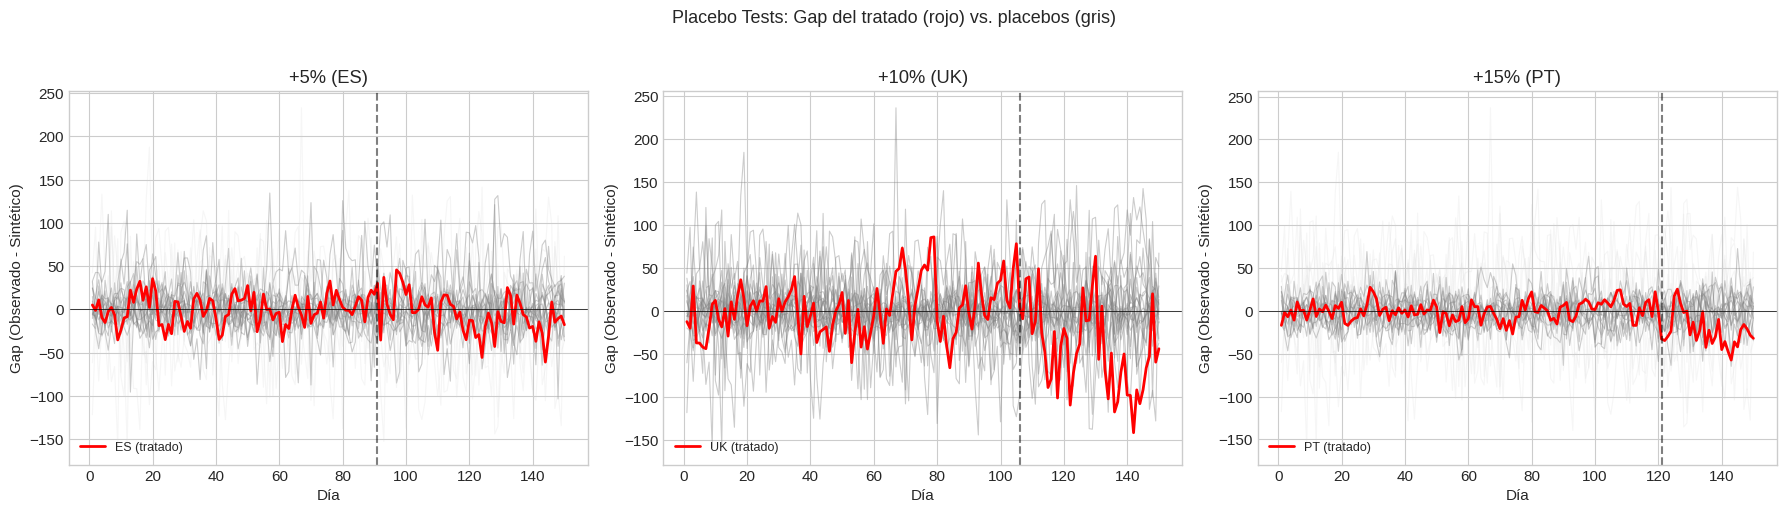

In [70]:
# =============================================================================
# Placebo Test con Fisher's Exact Inference
# =============================================================================
# Para cada brazo, fingimos que cada mercado de control fue tratado
# y corremos SCM con los restantes controles + el tratado real como donor.
# Comparamos el ratio RMSPE post/pre del tratado real vs. placebos.

def run_placebo_tests_fisher(df, treated_market, control_markets, treatment_day, outcome='bookings'):
    """
    Ejecuta placebo SCM para cada mercado de control,
    usando el resto de controles + el tratado real como donor pool.
    Calcula RMSPE ratio post/pre para inferencia de Fisher.
    """
    placebo_results = {}

    for placebo_market in control_markets:
        placebo_donors = [m for m in control_markets if m != placebo_market] + [treated_market]

        try:
            scm_placebo = compute_synthetic_control(
                df=df,
                treated_market=placebo_market,
                control_markets=placebo_donors,
                treatment_day=treatment_day,
                outcome=outcome
            )
            placebo_results[placebo_market] = scm_placebo
        except Exception as e:
            print(f"  Placebo {placebo_market} falló: {e}")

    return placebo_results


def compute_rmspe_ratio(scm_result):
    """Calcula ratio RMSPE post/pre."""
    t_day = scm_result['treatment_day']
    effect = scm_result['effect']
    days = scm_result['day_index']

    pre_effect = effect[days < t_day]
    post_effect = effect[days >= t_day]

    rmspe_pre = np.sqrt(np.mean(pre_effect**2))
    rmspe_post = np.sqrt(np.mean(post_effect**2))

    ratio = rmspe_post / rmspe_pre if rmspe_pre > 0 else np.inf
    return ratio, rmspe_pre, rmspe_post


# Ejecutar placebos para cada brazo
print("=" * 70)
print("PLACEBO TESTS (FISHER'S EXACT INFERENCE)")
print("=" * 70)

all_placebo_results = {}

for arm, info in TREATED_MARKETS.items():
    rep = info['representative']
    t_day = info['treatment_day']

    print(f"\n{'─' * 50}")
    print(f"Brazo {arm} ({rep}) - Treatment day {t_day}")
    print(f"{'─' * 50}")

    # Ratio del tratado real
    treated_ratio, treated_rmspe_pre, treated_rmspe_post = compute_rmspe_ratio(results[arm])
    print(f"  Tratado ({rep}): RMSPE pre={treated_rmspe_pre:.1f}, post={treated_rmspe_post:.1f}, ratio={treated_ratio:.2f}")

    # Placebos
    placebos = run_placebo_tests_fisher(df, rep, CONTROL_MARKETS, t_day)
    all_placebo_results[arm] = {
        'placebos': placebos,
        'treated_market': rep,
        'treatment_day': t_day
    }

    placebo_ratios = []
    for pm, scm_p in placebos.items():
        ratio_p, pre_p, post_p = compute_rmspe_ratio(scm_p)
        placebo_ratios.append(ratio_p)
        print(f"  Placebo ({pm}): RMSPE pre={pre_p:.1f}, post={post_p:.1f}, ratio={ratio_p:.2f}")

    # p-valor: fraccion de ratios (placebos + tratado) >= ratio tratado
    all_ratios = placebo_ratios + [treated_ratio]
    p_value = np.mean([r >= treated_ratio for r in all_ratios])
    rank = sorted(all_ratios, reverse=True).index(treated_ratio) + 1

    print(f"\n  Ratio tratado: {treated_ratio:.2f} (rank {rank}/{len(all_ratios)})")
    print(f"  p-valor (Fisher): {p_value:.3f}")
    if p_value <= 0.10:
        print(f"  → Efecto significativo al 10% (rank {rank} de {len(all_ratios)})")
    elif p_value <= 0.20:
        print(f"  → Efecto plausible pero no significativo al 10%")
    else:
        print(f"  → Efecto NO distinguible de placebos")
    print(f"  Nota: con {len(CONTROL_MARKETS)} controles, p-valor mínimo posible = {1/len(all_ratios):.3f}")


# =============================================================================
# Visualización: Placebo Plot (gap lines) con Fisher
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (arm, info) in enumerate(TREATED_MARKETS.items()):
    ax = axes[idx]
    rep = info['representative']
    t_day = info['treatment_day']
    placebos = all_placebo_results[arm]['placebos']

    # Líneas placebo en gris (filtrar los de RMSPE pre muy alto)
    for pm, scm_p in placebos.items():
        if scm_p['rmspe_pre'] > 3 * results[arm]['rmspe_pre']:
            ax.plot(scm_p['day_index'], scm_p['effect'], color='lightgray',
                    alpha=0.2, linewidth=0.8)
        else:
            ax.plot(scm_p['day_index'], scm_p['effect'], color='gray',
                    alpha=0.4, linewidth=0.8)

    # Línea del tratado real
    ax.plot(results[arm]['day_index'], results[arm]['effect'],
            color='red', linewidth=2, label=f'{rep} (tratado)')

    ax.axvline(x=t_day, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{arm} ({rep})')
    ax.set_xlabel('Día')
    ax.set_ylabel('Gap (Observado - Sintético)')
    ax.legend(loc='lower left', fontsize=9)

plt.suptitle('Placebo Tests: Gap del tratado (rojo) vs. placebos (gris)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Guardar para uso en visualización de placebo (compatibilidad con Cell 21)
placebo_results = {}
for arm, info in TREATED_MARKETS.items():
    rep = info['representative']
    t_day = info['treatment_day']
    placebos = all_placebo_results[arm]['placebos']
    placebo_results[arm] = {
        'treated': rep,
        'real_effect': results[arm]['effect'],
        'real_rmspe': results[arm]['rmspe_pre'],
        'placebo_effects': {pm: s['effect'] for pm, s in placebos.items()},
        'placebo_rmspe': {pm: s['rmspe_pre'] for pm, s in placebos.items()},
        'day_index': results[arm]['day_index'],
        'treatment_day': t_day
    }

In [71]:
# =============================================================================
# PLACEBO IN-TIME: TRATAMIENTO FALSO EN PRE-PERIODO
# =============================================================================

def placebo_in_time(df, treated_market, control_markets, real_treatment_day,
                    placebo_days=None):
    """
    Aplica tratamiento falso en pre-periodo.
    Si aparecen "efectos" significativos, el método puede estar capturando ruido.
    """
    if placebo_days is None:
        # Por defecto: 3 puntos equidistantes en pre-periodo
        placebo_days = [int(real_treatment_day * f) for f in [0.4, 0.6, 0.8]]

    results = []

    for placebo_day in placebo_days:
        if placebo_day >= real_treatment_day or placebo_day < 20:
            continue

        # SCM con tratamiento falso
        scm = compute_synthetic_control(df, treated_market, control_markets, placebo_day)

        # "Efecto" en el periodo placebo (entre placebo_day y real_treatment_day)
        mask = (scm['day_index'] >= placebo_day) & (scm['day_index'] < real_treatment_day)
        if mask.sum() == 0:
            continue

        fake_effect = np.mean(scm['effect'][mask])

        results.append({
            'placebo_day': placebo_day,
            'fake_att': fake_effect,
            'rmspe_pre': scm['rmspe_pre']
        })

    return pd.DataFrame(results) if results else pd.DataFrame()

print("="*70)
print("PLACEBO IN-TIME: TRATAMIENTO FALSO EN PRE-PERIODO")
print("="*70)
print("\nSi el método funciona, NO deberíamos ver efectos en pre-periodo.\n")

for arm, info in TREATED_MARKETS.items():
    market = info['representative']
    t_day = info['treatment_day']

    pit_df = placebo_in_time(df, market, CONTROL_MARKETS, t_day)

    print(f"{arm} ({market}):")
    if len(pit_df) > 0:
        print(pit_df.round(2).to_string(index=False))

        max_fake = pit_df['fake_att'].abs().max()
        real_att = abs(elasticity_df[elasticity_df['arm'] == arm]['att'].values[0]) if 'elasticity_df' in dir() else 20

        if max_fake < 15:  # Umbral absoluto si no tenemos elasticity_df aún
            print(f"  ✓ No hay efectos espurios en pre-periodo (max fake ATT: {max_fake:.1f})")
        else:
            print(f"  ⚠️ Posibles efectos espurios - revisar asunciones (max fake ATT: {max_fake:.1f})")
    else:
        print("  No hay suficientes datos para placebo in-time")
    print()

PLACEBO IN-TIME: TRATAMIENTO FALSO EN PRE-PERIODO

Si el método funciona, NO deberíamos ver efectos en pre-periodo.

+5% (ES):
 placebo_day  fake_att  rmspe_pre
          36      2.01      17.99
          54      1.28      18.35
          72      9.86      17.47
  ✓ No hay efectos espurios en pre-periodo (max fake ATT: 9.9)

+10% (UK):
 placebo_day  fake_att  rmspe_pre
          42     10.08      20.16
          63     25.24      21.91
          84     14.91      30.37
  ⚠️ Posibles efectos espurios - revisar asunciones (max fake ATT: 25.2)

+15% (PT):
 placebo_day  fake_att  rmspe_pre
          48      3.10       8.31
          72      7.12       8.80
          96     12.29       9.72
  ✓ No hay efectos espurios en pre-periodo (max fake ATT: 12.3)



UK (+10%) - BSTS Robustness Check
Pre-periodo: 2024-01-01 a 2024-04-14
Post-periodo: 2024-04-15 a 2024-05-29
Controles disponibles: 19 mercados



Visualización del análisis CausalImpact:


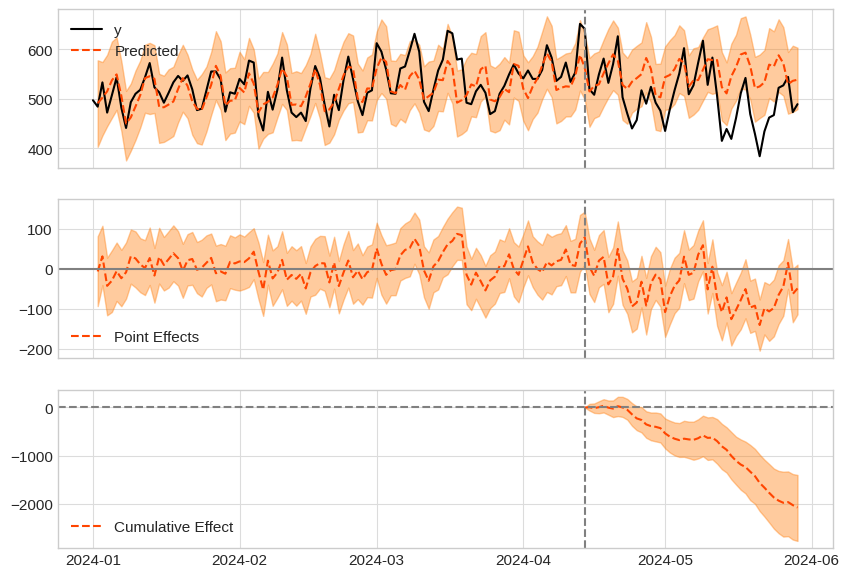

<Figure size 1200x600 with 0 Axes>



Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    503.71             22667.0
Prediction (s.d.)         549.97 (7.91)      24748.43 (355.74)
95% CI                    [535.01, 566.0]    [24075.35, 25469.83]

Absolute effect (s.d.)    -46.25 (7.91)      -2081.43 (355.74)
95% CI                    [-62.29, -31.3]    [-2802.83, -1408.35]

Relative effect (s.d.)    -8.41% (1.44%)     -8.41% (1.44%)
95% CI                    [-11.33%, -5.69%]  [-11.33%, -5.69%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 503.71. By contrast, in the absence of an
intervention, we would have expected an average response of 549.97.
The 95% interval of this counterfactual prediction is [535.01, 566.0].
Subtracting t

In [72]:
# =====================================================================
# ROBUSTNESS CHECK: BSTS / CausalImpact para UK (+10%)
# =====================================================================
# SCM diagnosticó HHI alto para UK: el sintético depende excesivamente de DE.
# Validamos con un método alternativo que no requiere convex hull.
#
# IMPORTANTE: fijar versión para reproducibilidad.
# !pip install -q tfcausalimpact==0.1.0

from causalimpact import CausalImpact
import warnings
warnings.filterwarnings('ignore')

# --- Preparar datos para CausalImpact ---
uk_data = df[df['market'] == 'UK'][['date', 'bookings']].copy()
uk_data['date'] = pd.to_datetime(uk_data['date'])
uk_data = uk_data.set_index('date').rename(columns={'bookings': 'UK'})

control_series = {}
for m in CONTROL_MARKETS:
    m_data = df[df['market'] == m][['date', 'bookings']].copy()
    m_data['date'] = pd.to_datetime(m_data['date'])
    m_data = m_data.set_index('date')
    control_series[m] = m_data['bookings']

control_df = pd.DataFrame(control_series)
ci_data = uk_data.join(control_df)

# Obtener fecha de tratamiento
uk_treatment_day = TREATED_MARKETS['+10%']['treatment_day']
treatment_date = df[df['day_index'] == uk_treatment_day]['date'].iloc[0]
treatment_date = pd.to_datetime(treatment_date)

# Periodos
pre_period = [str(ci_data.index.min().date()), str((treatment_date - pd.Timedelta(days=1)).date())]
post_period = [str(treatment_date.date()), str(ci_data.index.max().date())]

print(f"UK (+10%) - BSTS Robustness Check")
print(f"Pre-periodo: {pre_period[0]} a {pre_period[1]}")
print(f"Post-periodo: {post_period[0]} a {post_period[1]}")
print(f"Controles disponibles: {len(CONTROL_MARKETS)} mercados")
print(f"{'='*70}\n")

# --- Ejecutar CausalImpact ---
ci = CausalImpact(ci_data, pre_period, post_period)

# --- Visualización nativa ---
print("Visualización del análisis CausalImpact:")
ci.plot()
plt.tight_layout()
plt.show()

# --- Resumen numérico ---
print("\n")
print(ci.summary())
print("\n")
print(ci.summary(output='report'))

# --- Extraer resultados: fail loud, no fail silent ---
inferences = ci.inferences
post_mask = inferences.index >= treatment_date

REQUIRED_COLS = ['point_effects_means', 'point_effects_lower', 'point_effects_upper']
missing = [c for c in REQUIRED_COLS if c not in inferences.columns]
if missing:
    raise ValueError(
        f"Columnas no encontradas en CausalImpact inferences: {missing}. "
        f"Columnas disponibles: {list(inferences.columns)}. "
        f"Verifica la versión instalada de tfcausalimpact (esperada: 0.1.0)."
    )

bsts_att = inferences.loc[post_mask, 'point_effects_means'].mean()
bsts_lower = inferences.loc[post_mask, 'point_effects_lower'].mean()
bsts_upper = inferences.loc[post_mask, 'point_effects_upper'].mean()

# --- Comparación SCM vs BSTS con criterio duro ---
scm_att = results['+10%']['effect'][results['+10%']['day_index'] >= uk_treatment_day].mean()

print(f"\n{'='*70}")
print(f"COMPARACIÓN: SCM vs BSTS para UK (+10%)")
print(f"{'='*70}")
print(f"\n  SCM:  ATT = {scm_att:.1f} bookings/día")
print(f"        HHI = {results['+10%']['positivity']['hhi']:.3f} ⚠️")
print(f"        RMSPE = {results['+10%']['rmspe_pre']:.1f}")
print(f"\n  BSTS: ATT = {bsts_att:.1f} bookings/día")
print(f"        IC 95% = [{bsts_lower:.1f}, {bsts_upper:.1f}]")

# Criterio 1: Dirección
same_direction = (scm_att < 0 and bsts_att < 0) or (scm_att > 0 and bsts_att > 0)

# Criterio 2: SCM cae dentro del IC del BSTS
scm_in_bsts_ci = bsts_lower <= scm_att <= bsts_upper

# Criterio 3: Magnitud relativa
if min(abs(scm_att), abs(bsts_att)) > 0:
    magnitude_ratio = max(abs(scm_att), abs(bsts_att)) / min(abs(scm_att), abs(bsts_att))
else:
    magnitude_ratio = float('inf')

print(f"\n  Diagnóstico de concordancia:")
print(f"    Misma dirección:          {'✓' if same_direction else '✗'}")
print(f"    SCM dentro del IC BSTS:   {'✓' if scm_in_bsts_ci else '✗'}")
print(f"    Ratio de magnitud:        {magnitude_ratio:.1f}x {'✓' if magnitude_ratio < 2 else '⚠️' if magnitude_ratio < 3 else '✗'}")

# Veredicto
if same_direction and scm_in_bsts_ci:
    print(f"\n  → CONCORDANCIA FUERTE: ambos métodos convergen en dirección y magnitud.")
    print(f"    La estimación SCM es creíble a pesar del HHI alto.")
elif same_direction and magnitude_ratio < 2:
    print(f"\n  → CONCORDANCIA ACEPTABLE: misma dirección, magnitud comparable.")
    print(f"    Banda de estimación: [{min(scm_att, bsts_att):.1f}, {max(scm_att, bsts_att):.1f}] bookings/día.")
elif same_direction:
    print(f"\n  → CONCORDANCIA DÉBIL: misma dirección pero magnitud difiere {magnitude_ratio:.1f}x.")
    print(f"    Investigar qué donor/control drive la diferencia antes de decidir.")
else:
    print(f"\n  → DISCREPANCIA: los métodos no concuerdan. NO tomar decisión de pricing")
    print(f"    basada en este brazo hasta resolver la discrepancia.")

---

## 10. Resultados: De ATT a Elasticidad

### Cálculo de elasticidad

La elasticidad precio-demanda se calcula como:

```
ε = %ΔQ / %ΔP
```

**Importante**: Calculamos la elasticidad para cada brazo individualmente. La elasticidad NO es la pendiente de una regresión de %ΔQ vs %ΔP.

In [73]:
# Calcular ATT y elasticidad para cada brazo
print("RESULTADOS FINALES: ATT Y ELASTICIDAD")
print("="*70)

elasticity_data = []

for arm, scm in results.items():
    t_day = scm['treatment_day']
    market = scm['market']

    # Obtener datos del mercado para calcular ΔP realizado
    market_data = df[df['market'] == market].sort_values('day_index')
    pre_mask_data = market_data['day_index'] < t_day
    post_mask_data = market_data['day_index'] >= t_day

    # ΔP REALIZADO (no nominal) - First Stage
    price_pre = market_data.loc[pre_mask_data, 'price_eur'].mean()
    price_post = market_data.loc[post_mask_data, 'price_eur'].mean()
    pct_change_p = ((price_post - price_pre) / price_pre) * 100

    # ATT: promedio del efecto post-tratamiento
    post_mask = scm['day_index'] >= t_day
    att = np.mean(scm['effect'][post_mask])
    att_std = np.std(scm['effect'][post_mask])

    # Baseline: contrafactual sintético en post-periodo
    pre_mask = scm['day_index'] < t_day
    baseline_synthetic = np.mean(scm['synthetic'][post_mask])
    baseline_treated_pre = np.mean(scm['treated'][pre_mask])

    # Cambio porcentual en bookings (causal)
    pct_change_q = (att / baseline_synthetic) * 100

    # Elasticidad: %ΔQ / %ΔP
    elasticity = pct_change_q / pct_change_p

    elasticity_data.append({
        'arm': arm,
        'market': market,
        'price_change_realized': pct_change_p,
        'att': att,
        'att_std': att_std,
        'baseline_pre': baseline_treated_pre,
        'baseline_cf': baseline_synthetic,
        'pct_change_q': pct_change_q,
        'elasticity': elasticity,
        'rmspe_pre': scm['rmspe_pre']
    })

    print(f"\n{arm} ({market}):")
    print(f"  Baseline pre-tratamiento: {baseline_treated_pre:.0f} bookings/día")
    print(f"  Contrafactual (sintético): {baseline_synthetic:.0f} bookings/día")
    print(f"  ATT: {att:.1f} ± {att_std:.1f} bookings/día")
    print(f"  Cambio en precio (realizado): +{pct_change_p:.1f}%")
    print(f"  Cambio en bookings (causal): {pct_change_q:.1f}%")
    print(f"  Elasticidad precio-demanda: {elasticity:.2f}")

elasticity_df = pd.DataFrame(elasticity_data)

RESULTADOS FINALES: ATT Y ELASTICIDAD

+5% (ES):
  Baseline pre-tratamiento: 433 bookings/día
  Contrafactual (sintético): 447 bookings/día
  ATT: -6.1 ± 23.1 bookings/día
  Cambio en precio (realizado): +5.0%
  Cambio en bookings (causal): -1.4%
  Elasticidad precio-demanda: -0.27

+10% (UK):
  Baseline pre-tratamiento: 530 bookings/día
  Contrafactual (sintético): 548 bookings/día
  ATT: -44.5 ± 49.5 bookings/día
  Cambio en precio (realizado): +10.0%
  Cambio en bookings (causal): -8.1%
  Elasticidad precio-demanda: -0.81

+15% (PT):
  Baseline pre-tratamiento: 154 bookings/día
  Contrafactual (sintético): 160 bookings/día
  ATT: -23.3 ± 19.0 bookings/día
  Cambio en precio (realizado): +15.0%
  Cambio en bookings (causal): -14.6%
  Elasticidad precio-demanda: -0.97


In [74]:
# Tabla resumen final
print("\n" + "="*70)
print("TABLA RESUMEN")
print("="*70)

summary = elasticity_df[['arm', 'market', 'price_change_realized', 'att', 'pct_change_q', 'elasticity', 'rmspe_pre']].copy()
summary.columns = ['Brazo', 'Mercado', 'ΔP Realizado (%)', 'ATT (book/día)', 'ΔQ Causal (%)', 'Elasticidad', 'RMSPE Pre']
print(summary.round(2).to_string(index=False))


TABLA RESUMEN
Brazo Mercado  ΔP Realizado (%)  ATT (book/día)  ΔQ Causal (%)  Elasticidad  RMSPE Pre
  +5%      ES               5.0           -6.09          -1.36        -0.27      16.97
 +10%      UK              10.0          -44.55          -8.13        -0.81      31.39
 +15%      PT              15.0          -23.31         -14.56        -0.97      10.76


CURVA DE RESPUESTA PRECIO-DEMANDA

  Puntos observados (causales):
  Brazo      ΔP (%)   ΔQ (%)        ε  Rev. relativo
  ------------------------------------------------
  Base          0.0      0.0        -          1.000
  +5%         +5.0%    -1.4%    -0.27          1.027
  +10%       +10.0%    -8.1%    -0.81          1.020
  +15%       +15.0%   -14.6%    -0.97          0.979

  Curva interpolada (polinomio grado 2):
    %ΔQ = -0.0508·(%ΔP)² + -0.2477·(%ΔP) + 0.2864

  PRECIO ÓPTIMO (maximiza revenue):
    Incremento óptimo:    +6.5%
    Precio óptimo:        94.78 EUR
    Efecto en demanda:    -3.5%
    Efecto en revenue:    +2.8% vs baseline

    Break-even (revenue = baseline): +13.0%
    → Subidas por encima de +13% DESTRUYEN revenue


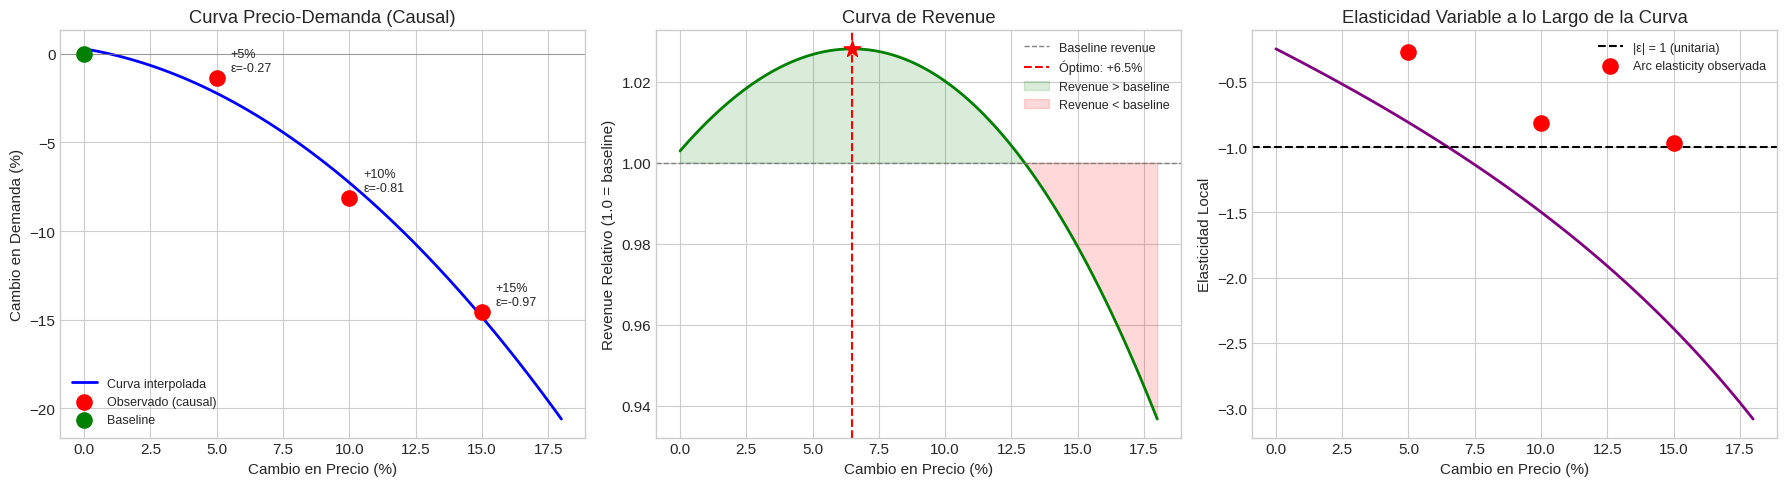


→ RECOMENDACIÓN: incremento óptimo de +6%.
  Por encima de ese nivel, cada punto adicional destruye más demanda de la que compensa el precio.


In [75]:
# =====================================================================
# CURVA DE RESPUESTA PRECIO-DEMANDA Y PRECIO ÓPTIMO
# =====================================================================
# En lugar de colapsar tres elasticidades en un promedio,
# interpolamos la curva completa y encontramos el precio que maximiza revenue.

from scipy.interpolate import UnivariateSpline
from scipy.optimize import minimize_scalar

# --- Datos observados: punto de control (0%, 0% cambio) + tres brazos ---
price_changes = np.array([0.0] + list(elasticity_df['price_change_realized']))
demand_changes = np.array([0.0] + list(elasticity_df['pct_change_q']))

# Baseline bookings y precio (del control sintético)
baseline_bookings = elasticity_df['baseline_cf'].mean()
baseline_price = df['base_price_eur'].iloc[0]

# --- Interpolar curva de demanda: %ΔQ = f(%ΔP) ---
# Polinomio grado 2: 3 brazos + origen = 4 puntos
sort_idx = np.argsort(price_changes)
pc_sorted = price_changes[sort_idx]
dc_sorted = demand_changes[sort_idx]

coeffs = np.polyfit(pc_sorted, dc_sorted, 2)
demand_curve = np.poly1d(coeffs)

# --- Curva de revenue relativo ---
# Revenue = P * Q = P_base*(1+%ΔP/100) * Q_base*(1+%ΔQ/100)
# Revenue relativo al baseline = (1+%ΔP/100) * (1+%ΔQ(%ΔP)/100)
def revenue_relative(pct_dp):
    pct_dq = demand_curve(pct_dp)
    return (1 + pct_dp/100) * (1 + pct_dq/100)

# --- Encontrar precio óptimo (maximizar revenue) ---
result = minimize_scalar(lambda x: -revenue_relative(x), bounds=(0, 20), method='bounded')
optimal_price_change = result.x
optimal_revenue_idx = revenue_relative(optimal_price_change)
optimal_demand_change = demand_curve(optimal_price_change)

print("=" * 70)
print("CURVA DE RESPUESTA PRECIO-DEMANDA")
print("=" * 70)

print(f"\n  Puntos observados (causales):")
print(f"  {'Brazo':<8} {'ΔP (%)':>8} {'ΔQ (%)':>8} {'ε':>8} {'Rev. relativo':>14}")
print(f"  {'-'*48}")
print(f"  {'Base':<8} {'0.0':>8} {'0.0':>8} {'-':>8} {'1.000':>14}")
for _, row in elasticity_df.iterrows():
    rev_rel = revenue_relative(row['price_change_realized'])
    print(f"  {row['arm']:<8} {row['price_change_realized']:>+7.1f}% {row['pct_change_q']:>+7.1f}% {row['elasticity']:>8.2f} {rev_rel:>14.3f}")

print(f"\n  Curva interpolada (polinomio grado 2):")
print(f"    %ΔQ = {coeffs[0]:.4f}·(%ΔP)² + {coeffs[1]:.4f}·(%ΔP) + {coeffs[2]:.4f}")

print(f"\n  {'='*48}")
print(f"  PRECIO ÓPTIMO (maximiza revenue):")
print(f"  {'='*48}")
print(f"    Incremento óptimo:    +{optimal_price_change:.1f}%")
print(f"    Precio óptimo:        {baseline_price * (1 + optimal_price_change/100):.2f} EUR")
print(f"    Efecto en demanda:    {optimal_demand_change:+.1f}%")
print(f"    Efecto en revenue:    {(optimal_revenue_idx - 1)*100:+.1f}% vs baseline")

# --- Zona segura vs zona de riesgo ---
from scipy.optimize import brentq
try:
    breakeven = brentq(lambda x: revenue_relative(x) - 1.0, optimal_price_change, 20)
    print(f"\n    Break-even (revenue = baseline): +{breakeven:.1f}%")
    print(f"    → Subidas por encima de +{breakeven:.0f}% DESTRUYEN revenue")
except:
    print(f"\n    Revenue se mantiene por encima del baseline en todo el rango analizado")

# --- Visualización ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dp_range = np.linspace(0, 18, 100)
dq_range = demand_curve(dp_range)
rev_range = np.array([revenue_relative(dp) for dp in dp_range])

# Panel 1: Curva de demanda
ax = axes[0]
ax.plot(dp_range, dq_range, 'b-', linewidth=2, label='Curva interpolada')
ax.scatter(elasticity_df['price_change_realized'], elasticity_df['pct_change_q'],
           s=120, color='red', zorder=5, label='Observado (causal)')
ax.scatter([0], [0], s=120, color='green', zorder=5, label='Baseline')
for _, row in elasticity_df.iterrows():
    ax.annotate(f"{row['arm']}\nε={row['elasticity']:.2f}",
                (row['price_change_realized'], row['pct_change_q']),
                textcoords="offset points", xytext=(10, 5), fontsize=9)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_xlabel('Cambio en Precio (%)')
ax.set_ylabel('Cambio en Demanda (%)')
ax.set_title('Curva Precio-Demanda (Causal)')
ax.legend(fontsize=9)

# Panel 2: Revenue relativo
ax = axes[1]
ax.plot(dp_range, rev_range, 'g-', linewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='Baseline revenue')
ax.axvline(x=optimal_price_change, color='red', linestyle='--',
           label=f'Óptimo: +{optimal_price_change:.1f}%')
ax.scatter([optimal_price_change], [optimal_revenue_idx],
           s=150, color='red', zorder=5, marker='*')
ax.fill_between(dp_range, 1.0, rev_range,
                where=(rev_range >= 1.0), alpha=0.15, color='green', label='Revenue > baseline')
ax.fill_between(dp_range, 1.0, rev_range,
                where=(rev_range < 1.0), alpha=0.15, color='red', label='Revenue < baseline')
ax.set_xlabel('Cambio en Precio (%)')
ax.set_ylabel('Revenue Relativo (1.0 = baseline)')
ax.set_title('Curva de Revenue')
ax.legend(fontsize=9)

# Panel 3: Elasticidad local a lo largo de la curva
ax = axes[2]
deriv = np.polyder(demand_curve)
elasticity_local = deriv(dp_range) * (1 + dp_range/100) / (1 + dq_range/100)
ax.plot(dp_range, elasticity_local, 'purple', linewidth=2)
ax.axhline(y=-1, color='black', linestyle='--', label='|ε| = 1 (unitaria)')
ax.scatter(elasticity_df['price_change_realized'], elasticity_df['elasticity'],
           s=120, color='red', zorder=5, label='Arc elasticity observada')
ax.set_xlabel('Cambio en Precio (%)')
ax.set_ylabel('Elasticidad Local')
ax.set_title('Elasticidad Variable a lo Largo de la Curva')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n→ RECOMENDACIÓN: incremento óptimo de +{optimal_price_change:.0f}%.")
print(f"  Por encima de ese nivel, cada punto adicional destruye más demanda de la que compensa el precio.")

---

## 11. Análisis de Impacto en Revenue

### La pregunta clave para el negocio

```
Revenue = Precio × Cantidad
```

Si la demanda es **inelástica** (|ε| < 1): subir precio → revenue SUBE

Si la demanda es **elástica** (|ε| > 1): subir precio → revenue BAJA

In [76]:
# Calcular impacto en revenue usando el contrafactual sintético
print("="*70)
print("ANÁLISIS DE IMPACTO EN REVENUE")
print("="*70)

revenue_analysis = []

for arm, info in TREATED_MARKETS.items():
    market = info['representative']
    t_day = info['treatment_day']
    scm_result = results[arm]

    price_base = df['base_price_eur'].iloc[0]
    price_new = price_base * (1 + float(arm.replace('%','').replace('+',''))/100)

    market_data = df[df['market'] == market].copy()
    market_data = market_data.sort_values('day_index').reset_index(drop=True)

    synthetic_series = scm_result['synthetic']
    post_indices = market_data['day_index'] >= t_day

    bookings_observed = market_data.loc[post_indices, 'bookings'].mean()
    bookings_synthetic = synthetic_series[post_indices.values].mean()

    revenue_observed = bookings_observed * price_new
    revenue_counterfactual = bookings_synthetic * price_base

    delta_revenue = revenue_observed - revenue_counterfactual
    pct_delta_revenue = (delta_revenue / revenue_counterfactual) * 100

    n_days_post = post_indices.sum()
    total_delta_revenue = delta_revenue * n_days_post

    revenue_analysis.append({
        'arm': arm,
        'market': market,
        'price_base': price_base,
        'price_new': price_new,
        'bookings_obs': bookings_observed,
        'bookings_cf': bookings_synthetic,
        'revenue_obs': revenue_observed,
        'revenue_cf': revenue_counterfactual,
        'delta_revenue_daily': delta_revenue,
        'pct_delta_revenue': pct_delta_revenue,
        'n_days': n_days_post,
        'total_delta_revenue': total_delta_revenue
    })

    print(f"\n{arm} ({market}):")
    print(f"  Precio: {price_base:.0f} EUR → {price_new:.0f} EUR ({arm})")
    print(f"  Bookings observados:     {bookings_observed:.0f}/día")
    print(f"  Bookings contrafactual:  {bookings_synthetic:.0f}/día (sintético)")
    print(f"  Revenue observado:       {revenue_observed:,.0f} EUR/día")
    print(f"  Revenue contrafactual:   {revenue_counterfactual:,.0f} EUR/día")
    print(f"  Delta Revenue:           {delta_revenue:+,.0f} EUR/día ({pct_delta_revenue:+.1f}%)")
    print(f"  Impacto total ({n_days_post} días): {total_delta_revenue:+,.0f} EUR")

revenue_df = pd.DataFrame(revenue_analysis)

ANÁLISIS DE IMPACTO EN REVENUE

+5% (ES):
  Precio: 89 EUR → 93 EUR (+5%)
  Bookings observados:     441/día
  Bookings contrafactual:  447/día (sintético)
  Revenue observado:       41,218 EUR/día
  Revenue contrafactual:   39,797 EUR/día
  Delta Revenue:           +1,421 EUR/día (+3.6%)
  Impacto total (60 días): +85,247 EUR

+10% (UK):
  Precio: 89 EUR → 98 EUR (+10%)
  Bookings observados:     504/día
  Bookings contrafactual:  548/día (sintético)
  Revenue observado:       49,313 EUR/día
  Revenue contrafactual:   48,795 EUR/día
  Delta Revenue:           +518 EUR/día (+1.1%)
  Impacto total (45 días): +23,319 EUR

+15% (PT):
  Precio: 89 EUR → 102 EUR (+15%)
  Bookings observados:     137/día
  Bookings contrafactual:  160/día (sintético)
  Revenue observado:       13,995 EUR/día
  Revenue contrafactual:   14,244 EUR/día
  Delta Revenue:           -249 EUR/día (-1.7%)
  Impacto total (30 días): -7,469 EUR


---

## 12. Análisis de Guardrails

Monitoreamos métricas de protección:
- **LTV (Lifetime Value)**
- **Churn Rate**
- **CR Checkout→Sale**

In [77]:
# Análisis de Guardrails
print("="*70)
print("ANÁLISIS DE GUARDRAILS")
print("="*70)

guardrail_metrics = ['ltv_eur', 'churn_rate', 'cr_checkout_to_sale']
guardrail_names = {'ltv_eur': 'LTV (EUR)', 'churn_rate': 'Churn Rate', 'cr_checkout_to_sale': 'CR Checkout→Sale'}

guardrail_results = []

for arm, info in TREATED_MARKETS.items():
    market = info['representative']
    t_day = info['treatment_day']

    print(f"\n{arm} ({market}):")
    print("-" * 40)

    for metric in guardrail_metrics:
        try:
            scm_guard = compute_synthetic_control(
                df=df,
                treated_market=market,
                control_markets=CONTROL_MARKETS,
                treatment_day=t_day,
                outcome=metric
            )

            post_mask = scm_guard['day_index'] >= t_day
            att_guard = np.mean(scm_guard['effect'][post_mask])
            baseline_guard = np.mean(scm_guard['synthetic'][post_mask])
            pct_change_guard = (att_guard / baseline_guard) * 100 if baseline_guard != 0 else 0

            is_concerning = False
            if metric == 'ltv_eur' and pct_change_guard < -5:
                is_concerning = True
            elif metric == 'churn_rate' and pct_change_guard > 10:
                is_concerning = True
            elif metric == 'cr_checkout_to_sale' and pct_change_guard < -10:
                is_concerning = True

            status = "⚠️ REVISAR" if is_concerning else "✓ OK"
            print(f"  {guardrail_names[metric]}: {pct_change_guard:+.1f}% {status}")

            guardrail_results.append({
                'arm': arm,
                'market': market,
                'metric': metric,
                'pct_change': pct_change_guard,
                'status': 'concerning' if is_concerning else 'ok'
            })
        except:
            print(f"  {guardrail_names[metric]}: No calculable")

guardrails_df = pd.DataFrame(guardrail_results)

print("\n" + "="*70)
print("RESUMEN GUARDRAILS")
print("="*70)
concerning = guardrails_df[guardrails_df['status'] == 'concerning']
if len(concerning) == 0:
    print("✓ Todos los guardrails dentro de límites aceptables")
else:
    print("⚠️ Guardrails con señales de alerta:")
    for _, row in concerning.iterrows():
        print(f"   - {row['arm']} ({row['market']}): {guardrail_names[row['metric']]} = {row['pct_change']:+.1f}%")

ANÁLISIS DE GUARDRAILS

+5% (ES):
----------------------------------------
  LTV (EUR): -0.4% ✓ OK
  Churn Rate: +0.6% ✓ OK
  CR Checkout→Sale: -0.8% ✓ OK

+10% (UK):
----------------------------------------
  LTV (EUR): +0.0% ✓ OK
  Churn Rate: +0.2% ✓ OK
  CR Checkout→Sale: -2.1% ✓ OK

+15% (PT):
----------------------------------------
  LTV (EUR): -0.0% ✓ OK
  Churn Rate: -4.3% ✓ OK
  CR Checkout→Sale: -2.3% ✓ OK

RESUMEN GUARDRAILS
✓ Todos los guardrails dentro de límites aceptables


---

## 13. Resumen Ejecutivo

In [78]:
# Resumen ejecutivo
print("="*70)
print("RESUMEN EJECUTIVO - EXPERIMENTO DE PRICING")
print("="*70)

print("\n+===================================================================+")
print("|            RESULTADOS DEL EXPERIMENTO DE PRICING                  |")
print("+===================================================================+")

print(f"\n| DISEÑO DEL EXPERIMENTO                                           |")
print(f"|   - Mercados analizados: {len(CONTROL_MARKETS)} controles + 3 tratados              |")
print(f"|   - Periodo: {df['date'].min()} a {df['date'].max()}                        |")
print(f"|   - Metodología: Synthetic Control Method (causal)               |")

print("\n+-------------------------------------------------------------------+")
print("| EFECTOS CAUSALES ESTIMADOS (ATT)                                  |")
print("+-------------------------------------------------------------------+")

for _, row in elasticity_df.iterrows():
    arm = row['arm']
    market = row['market']
    att = row['att']
    pct_q = row['pct_change_q']
    print(f"|   {arm:>4} ({market}): ATT = {att:>6.1f} bookings/día ({pct_q:>+5.1f}%)             |")

print("\n+-------------------------------------------------------------------+")
print("| ELASTICIDAD PRECIO-DEMANDA                                        |")
print("+-------------------------------------------------------------------+")
print(f"|                                                                   |")
for _, row in elasticity_df.iterrows():
    print(f"|   {row['arm']:>4} ({row['market']}): ε = {row['elasticity']:.2f}                                      |")
print(f"|                                                                   |")

print("\n+-------------------------------------------------------------------+")
print("| PRECIO ÓPTIMO (curva de demanda interpolada)                      |")
print("+-------------------------------------------------------------------+")
print(f"|                                                                   |")
print(f"|   Incremento óptimo:  +{optimal_price_change:.1f}%                                    |")
print(f"|   Precio óptimo:      {baseline_price * (1 + optimal_price_change/100):.2f} EUR                                |")
print(f"|   Efecto en revenue:  {(optimal_revenue_idx - 1)*100:+.1f}% vs baseline                         |")
print(f"|                                                                   |")
print(f"|   RECOMENDACIÓN:                                                  |")
print(f"|   Subidas hasta +{optimal_price_change:.0f}% AUMENTAN revenue.                         |")
try:
    print(f"|   Por encima de +{breakeven:.0f}% se DESTRUYE revenue.                        |")
except NameError:
    print(f"|   Revenue se mantiene por encima del baseline en todo el rango.   |")

print("\n+-------------------------------------------------------------------+")
print("| VALIDACIÓN Y DIAGNÓSTICOS                                         |")
print("+-------------------------------------------------------------------+")
for _, row in elasticity_df.iterrows():
    rmspe = row['rmspe_pre']
    quality = "Excelente" if rmspe < 15 else "Bueno" if rmspe < 30 else "Aceptable"
    print(f"|   {row['arm']:>4} ({row['market']}): RMSPE = {rmspe:.1f} ({quality})                           |")

print("\n+===================================================================+")

RESUMEN EJECUTIVO - EXPERIMENTO DE PRICING

+===================================================================+
|            RESULTADOS DEL EXPERIMENTO DE PRICING                  |
+===================================================================+

| DISEÑO DEL EXPERIMENTO                                           |
|   - Mercados analizados: 19 controles + 3 tratados              |
|   - Periodo: 2024-01-01 a 2024-05-29                        |
|   - Metodología: Synthetic Control Method (causal)               |

+-------------------------------------------------------------------+
| EFECTOS CAUSALES ESTIMADOS (ATT)                                  |
+-------------------------------------------------------------------+
|    +5% (ES): ATT =   -6.1 bookings/día ( -1.4%)             |
|   +10% (UK): ATT =  -44.5 bookings/día ( -8.1%)             |
|   +15% (PT): ATT =  -23.3 bookings/día (-14.6%)             |

+-------------------------------------------------------------------+
|

---

## 14. Conclusiones y Limitaciones

### Hallazgos principales

1. **El Synthetic Control Method** permite estimar efectos causales en pricing cuando A/B testing no es viable.

2. **Los diagnósticos son clave**: RMSPE bajo en pre-periodo valida la asunción de aproximabilidad.

3. **Tres puntos permiten estimar la curva**: Con +5%, +10%, +15% caracterizamos la relación precio-demanda.

### Limitaciones

- **Validez local**: Resultados aplican a mercados similares en el periodo analizado
- **Corto plazo**: Efectos de largo plazo en marca/lealtad no capturados
- **Muchos controles pero test solo en un mercado**: La potencia estadística es limitada por tener un solo mercado tratado por brazo, no por falta de controles.

---

## Referencias

1. **Hernán, M. A., & Robins, J. M.** (2020). *Causal Inference: What If*. Chapman & Hall/CRC.

2. **Abadie, A., Diamond, A., & Hainmueller, J.** (2010). Synthetic control methods for comparative case studies. *JASA*, 105(490), 493-505.

3. **Abadie, A.** (2021). Using synthetic controls: Feasibility, data requirements, and methodological aspects. *JEL*, 59(2), 391-425.

4. **Facure, M.** (2022). *Causal Inference for the Brave and True*.

---

*Notebook creado siguiendo principios de inferencia causal rigurosa para experimentación en pricing.*